## 1. Import Libraries

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math 
import scipy.stats as stats
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [29]:
df = pd.read_csv('dataset/amazon_delivery.csv')
df = df.drop(columns='Order_ID')
y_target = 'Delivery_Time'
df.head(5)

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


## 3. Dataset Overview

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Agent_Age        43739 non-null  int64  
 1   Agent_Rating     43685 non-null  float64
 2   Store_Latitude   43739 non-null  float64
 3   Store_Longitude  43739 non-null  float64
 4   Drop_Latitude    43739 non-null  float64
 5   Drop_Longitude   43739 non-null  float64
 6   Order_Date       43739 non-null  object 
 7   Order_Time       43739 non-null  object 
 8   Pickup_Time      43739 non-null  object 
 9   Weather          43648 non-null  object 
 10  Traffic          43739 non-null  object 
 11  Vehicle          43739 non-null  object 
 12  Area             43739 non-null  object 
 13  Delivery_Time    43739 non-null  int64  
 14  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(8)
memory usage: 5.0+ MB


In [31]:
df.shape

(43739, 15)

In [32]:
df.describe()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [33]:
df.describe(include='object')

,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Category
count,43739,43739,43739,43648,43739,43739,43739,43739
unique,44,177,193,6,5,4,4,16
top,2022-03-15,21:55:00,21:30:00,Fog,Low,motorcycle,Metropolitian,Electronics
freq,1141,460,481,7440,14999,25527,32698,2849


## 4. Missing & Duplicate Values Analysis

In [34]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage
Agent_Rating,54,0.12
Weather,91,0.21


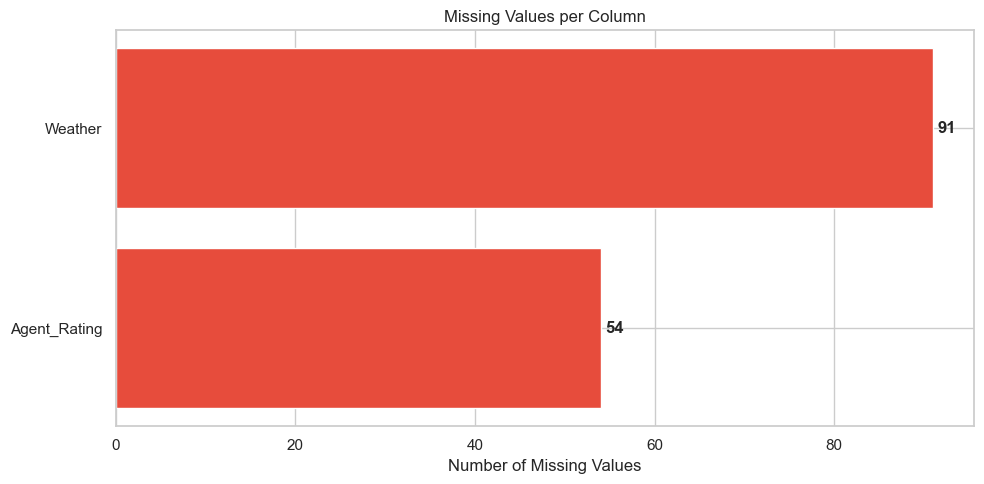

In [35]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+0.5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage


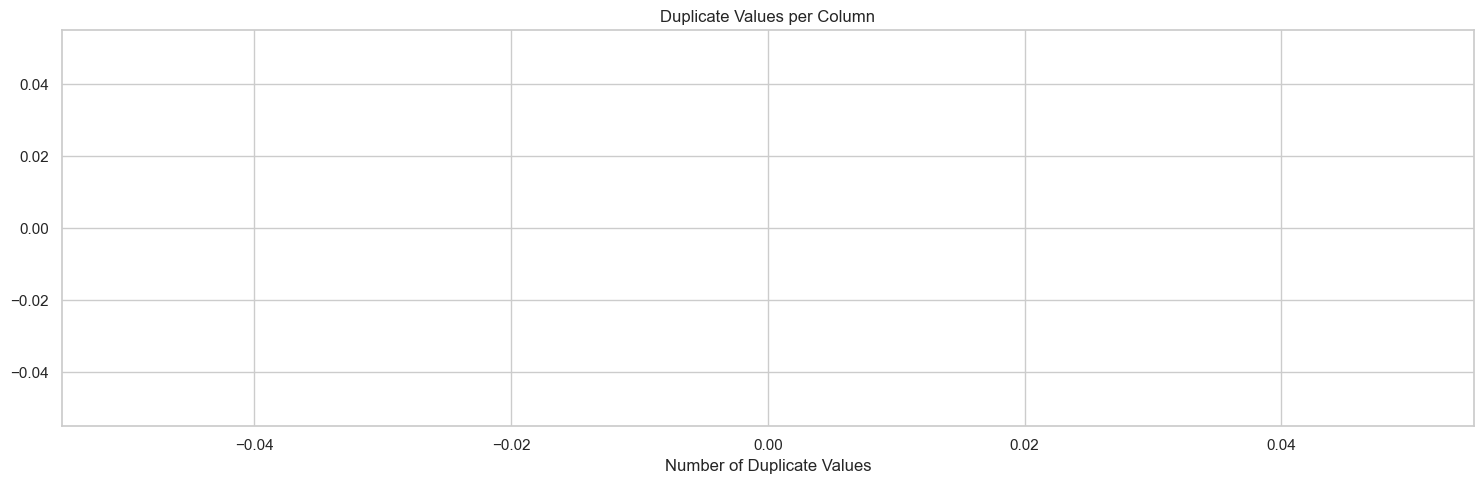

In [37]:
fig,ax = plt.subplots(figsize=(15,5))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+0.005,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Target Variabel Distribution

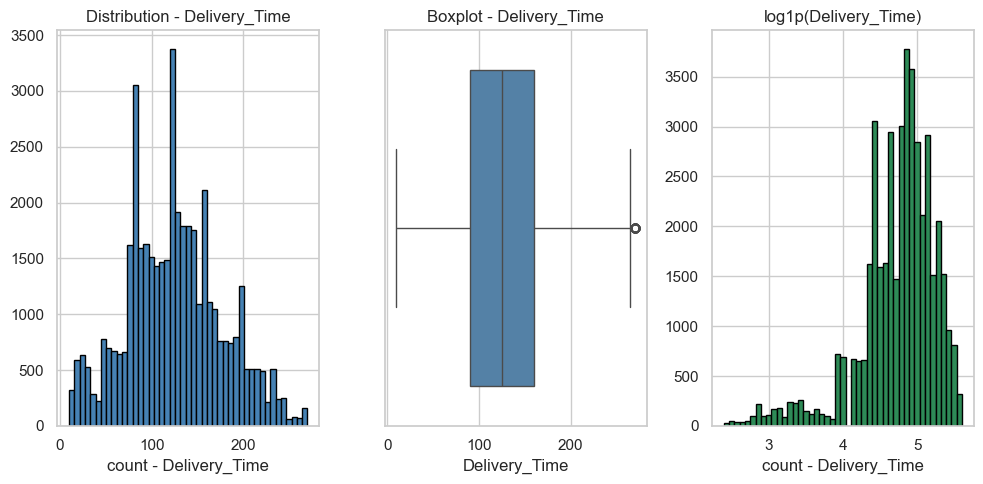

In [38]:
fig,axes = plt.subplots(1,3,figsize=(10,5))
axes[0].hist(df[y_target].dropna(),bins=45,color='steelblue',edgecolor='black')
axes[0].set_title(f'Distribution - {y_target}')
axes[0].set_xlabel(f'count - {y_target}')

sns.boxplot(x=df[y_target].dropna(),ax = axes[1],color='steelblue')
axes[1].set_title(f'Boxplot - {y_target}') 

axes[2].hist(np.log1p(df[y_target].dropna()),bins=45,color='seagreen',edgecolor='black')
axes[2].set_title(f'log1p({y_target})')
axes[2].set_xlabel(f'count - {y_target}')
plt.tight_layout()
plt.show()

In [39]:
describe = df[y_target].describe().round(3) #sudah berbentuk dataframe
y_stats = pd.DataFrame({
    y_target: [round(df[y_target].skew(), 3), round(df[y_target].kurtosis(), 3)]
},index=['Skewness', 'Kurtosis'])
df_stats = pd.concat([describe,y_stats]).T
df_stats

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
Delivery_Time,43739.0,124.906,51.915,10.0,90.0,125.0,160.0,270.0,0.189,-0.261


## 6. Univariat Analysis -- Numerical Features

In [40]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
ignored_features = [y_target]
feature_numerik = [col for col in feature_numerik if col not in ignored_features]

print(f'Numeric features ({len(feature_numerik)}):')
print(feature_numerik[:30])

Numeric features (6):
['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']


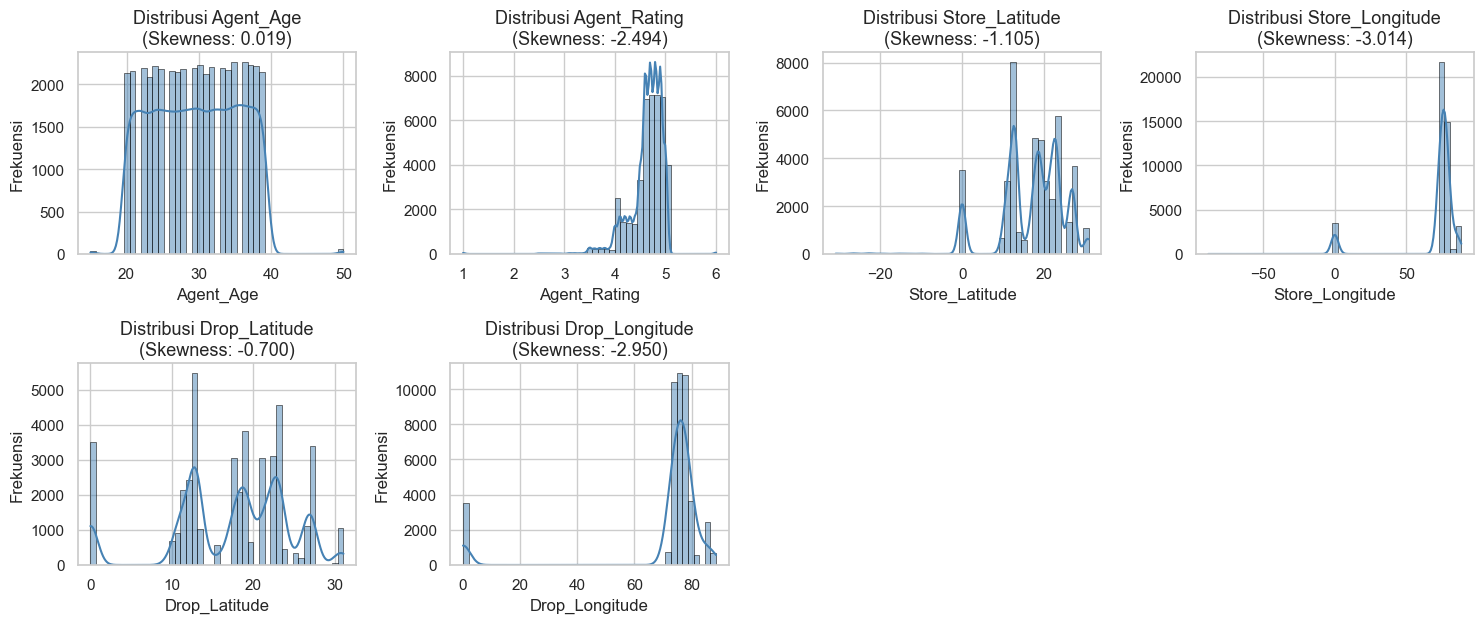

In [41]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='steelblue',edgecolor='black',bins=45)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

## 7. Univariate Analysis -- Categorical Features

In [42]:
feature_time = ['Order_Date', 'Order_Time', 'Pickup_Time']
feature_categori = df.select_dtypes(include='object').columns.drop(feature_time).to_list()
print(f'Numeric features ({len(feature_categori)}):')
print(feature_categori[:30]) 

Numeric features (5):
['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']


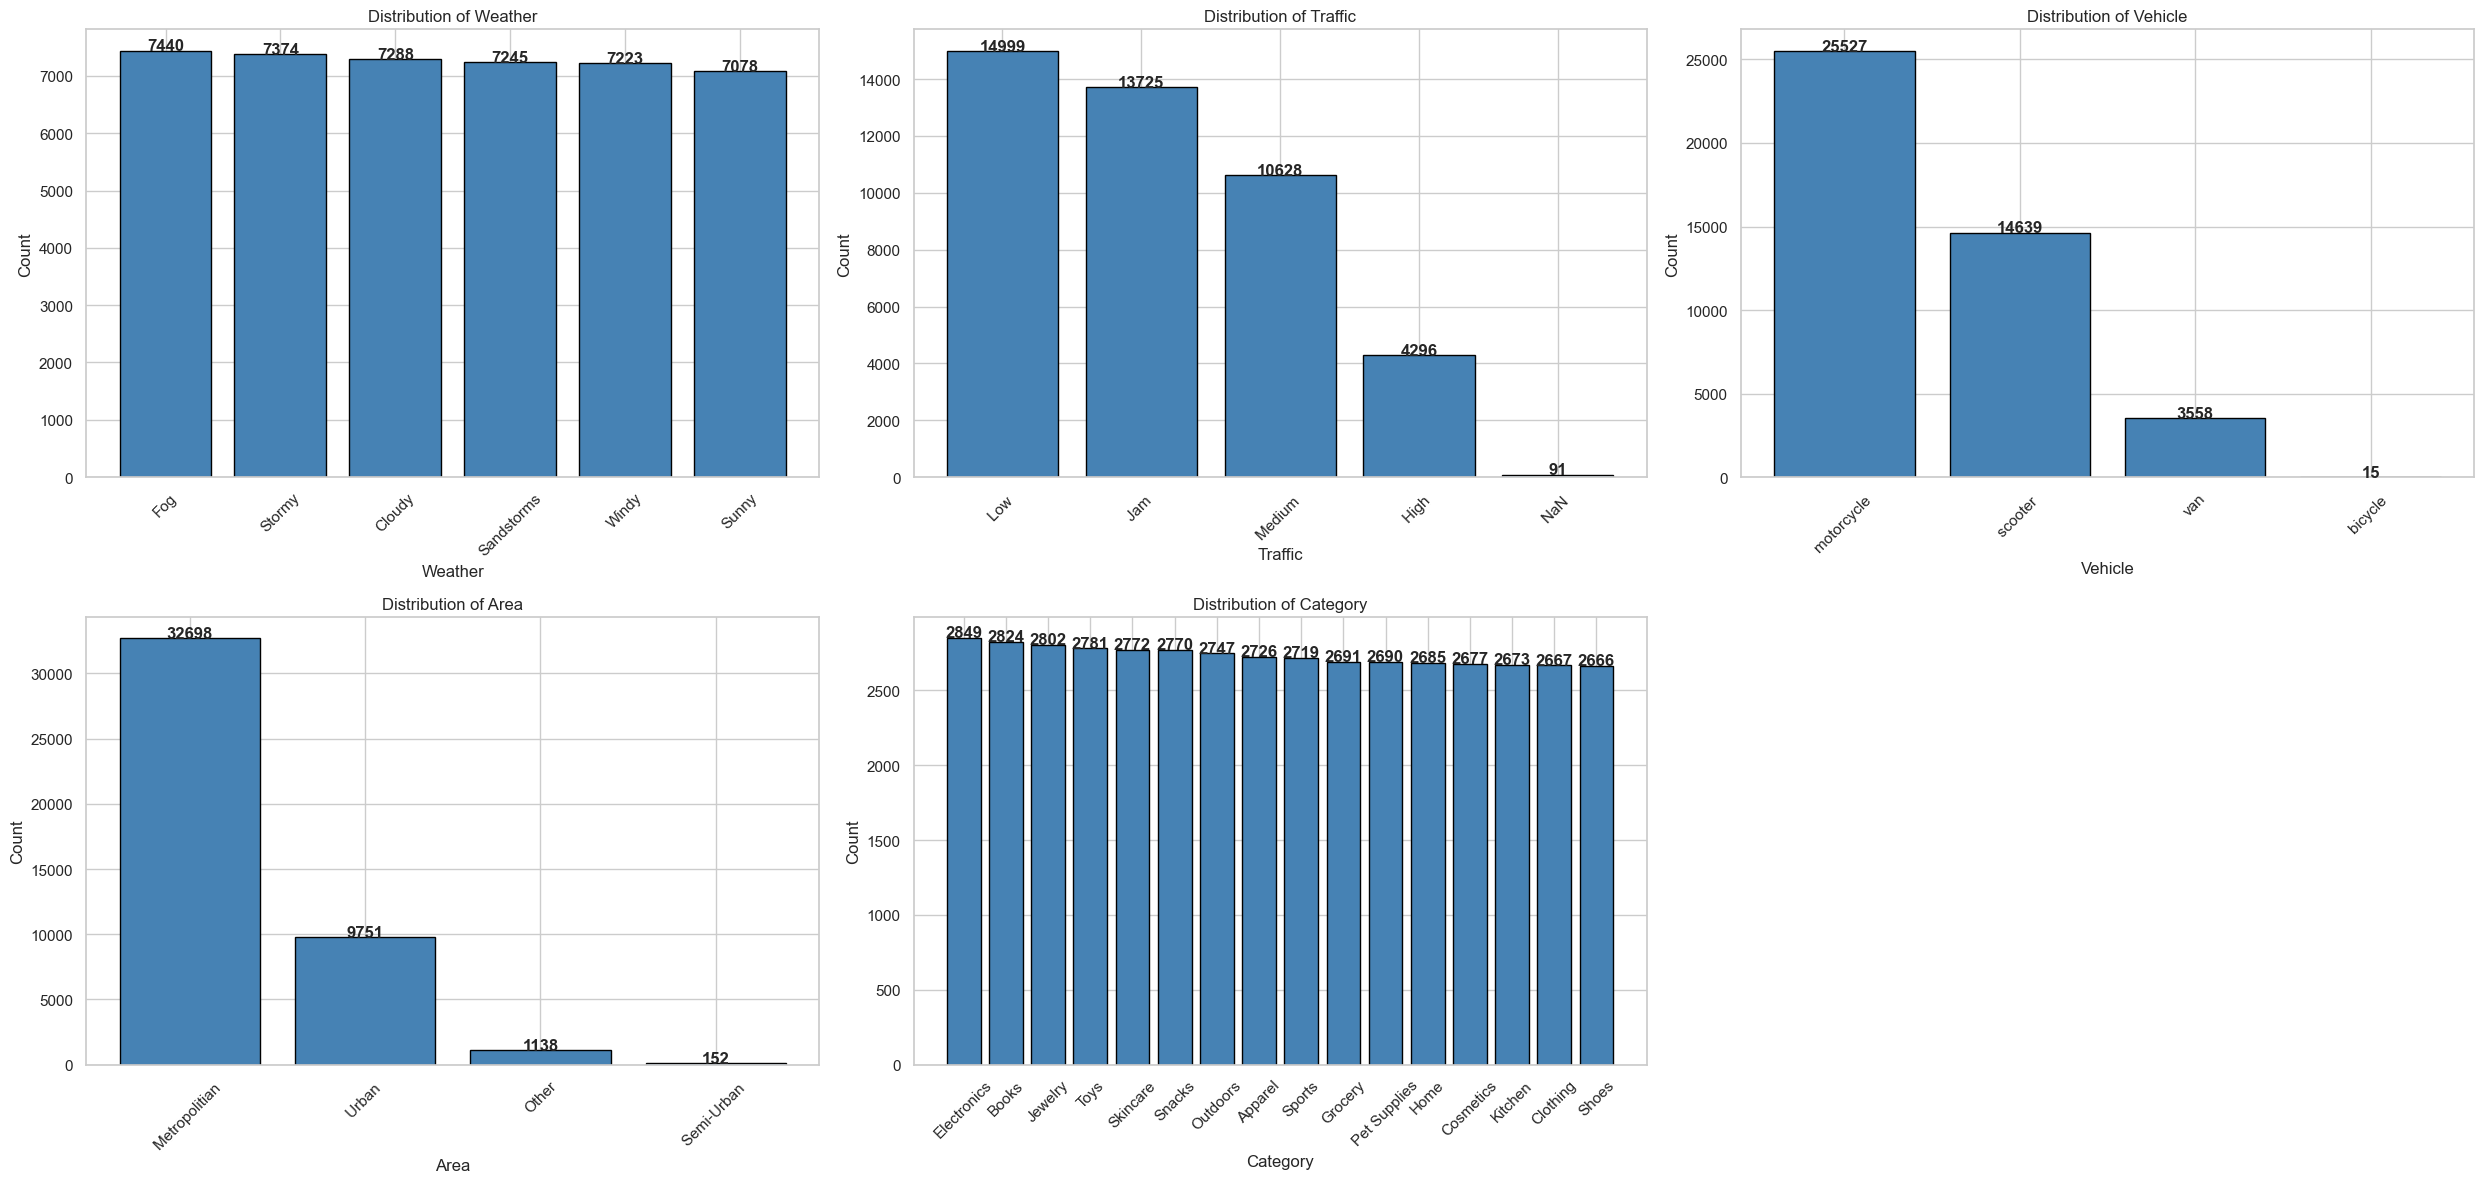

In [43]:
n_show = len(feature_categori)
n_cols = 3
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(25,6*nrows))
axes = axes.flatten()
for i,feature in enumerate(feature_categori):
    counts = df[feature].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor="black")
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha="center", fontweight="bold")
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis -- Features Numeric VS Target

In [44]:
feature_numerik = df.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Agent_Rating       0.290
Agent_Age          0.255
Store_Latitude     0.017
Drop_Latitude      0.017
Drop_Longitude     0.012
Store_Longitude    0.011
Name: Delivery_Time, dtype: float64


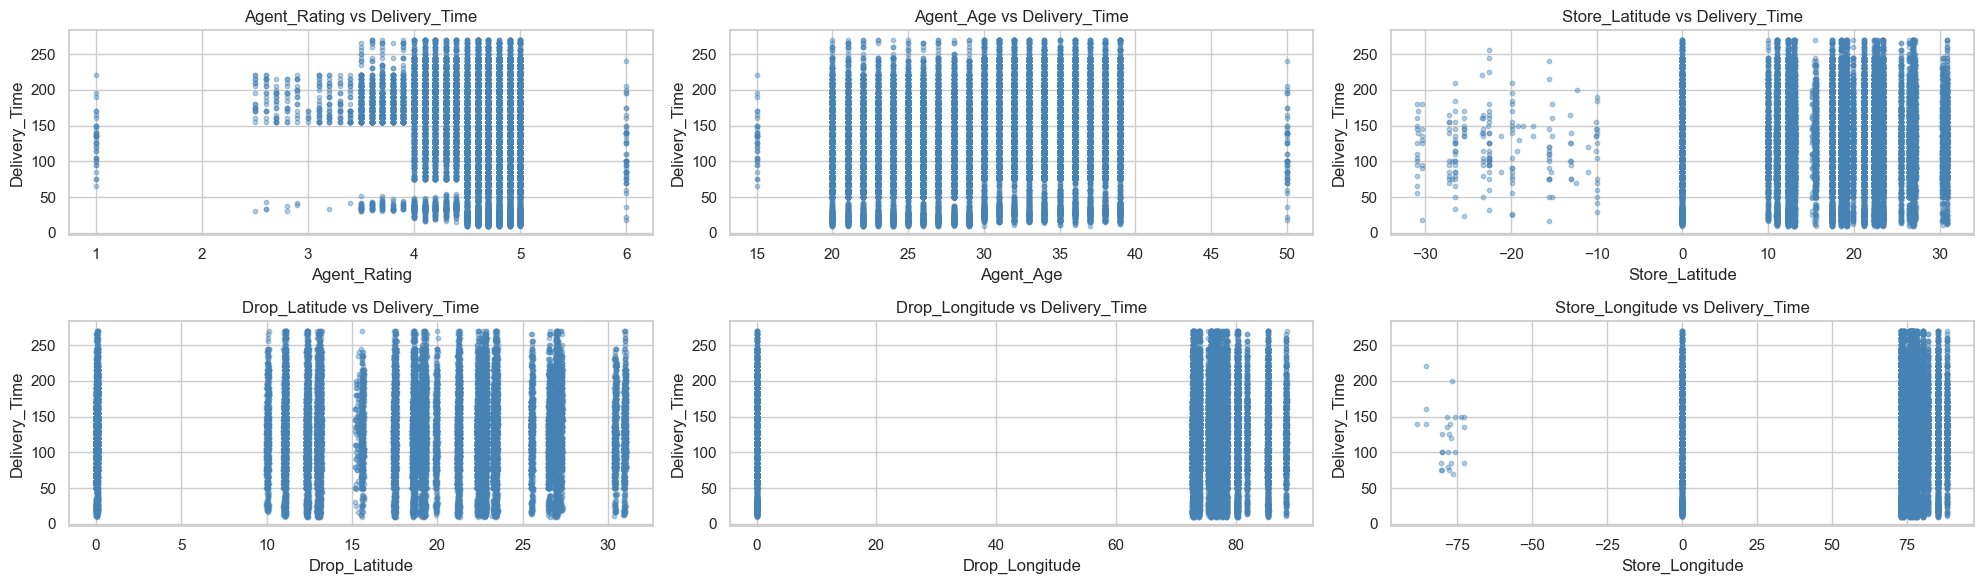

In [45]:
n_show = len(top_features)
n_cols = 3
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(20,3.0*nrows))
axes = axes.flatten()
for i,feature in enumerate(top_features):
    axes[i].scatter(df[feature],df[y_target],alpha=0.4,s=10,color='steelblue')
    axes[i].set_xlabel(feature); axes[i].set_ylabel(f'{y_target}')
    axes[i].set_title(f'{feature} vs {y_target}')
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

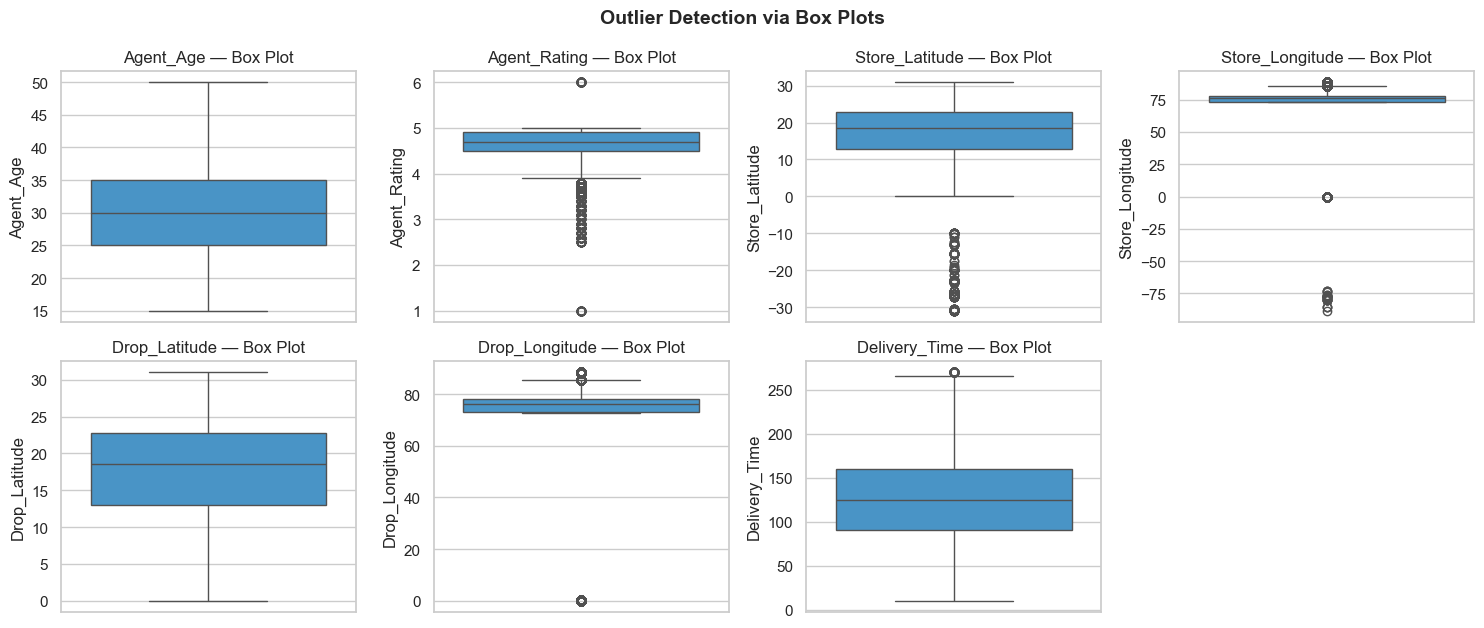

In [46]:
n_show = len(feature_numerik)
n_cols = 4
nrows = math.ceil(n_show/n_cols)

fig,axes = plt.subplots(nrows,n_cols,figsize=(15,3.2*nrows))
axes = axes.flatten()
for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(f"{col} — Box Plot")
for j in range(n_show, len(axes)):
        axes[j].axis('off')

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Bivariate Analysis -- Features Categoric VS Target

In [47]:
anova_results = []
for col in feature_categori:
    categories = df[col].dropna().unique()
    groups = [df[df[col] == cat][y_target].dropna() for  cat in categories]

    try:
        f_stats, p_val = stats.f_oneway(*groups)
        conclusion = "Signifikan" if p_val < 0.05 else "Tidak Signifikan"
        anova_results.append({
            'Feature': col,
            'F-Statistic': round(f_stats),
            'P-Value': round(p_val,1),
            'Conclusion': conclusion
        })
    except Exception as e:
        print(f"Gagal melakukan uji ANOVA untuk kolom {col}: {e}")
df_anova = pd.DataFrame(anova_results)
df_anova = df_anova.sort_values(by='F-Statistic',ascending=False).reset_index(drop=True)
df_anova

,Feature,F-Statistic,P-Value,Conclusion
0,Traffic,1670,0.0,Signifikan
1,Category,898,0.0,Signifikan
2,Area,717,0.0,Signifikan
3,Weather,433,0.0,Signifikan
4,Vehicle,290,0.0,Signifikan


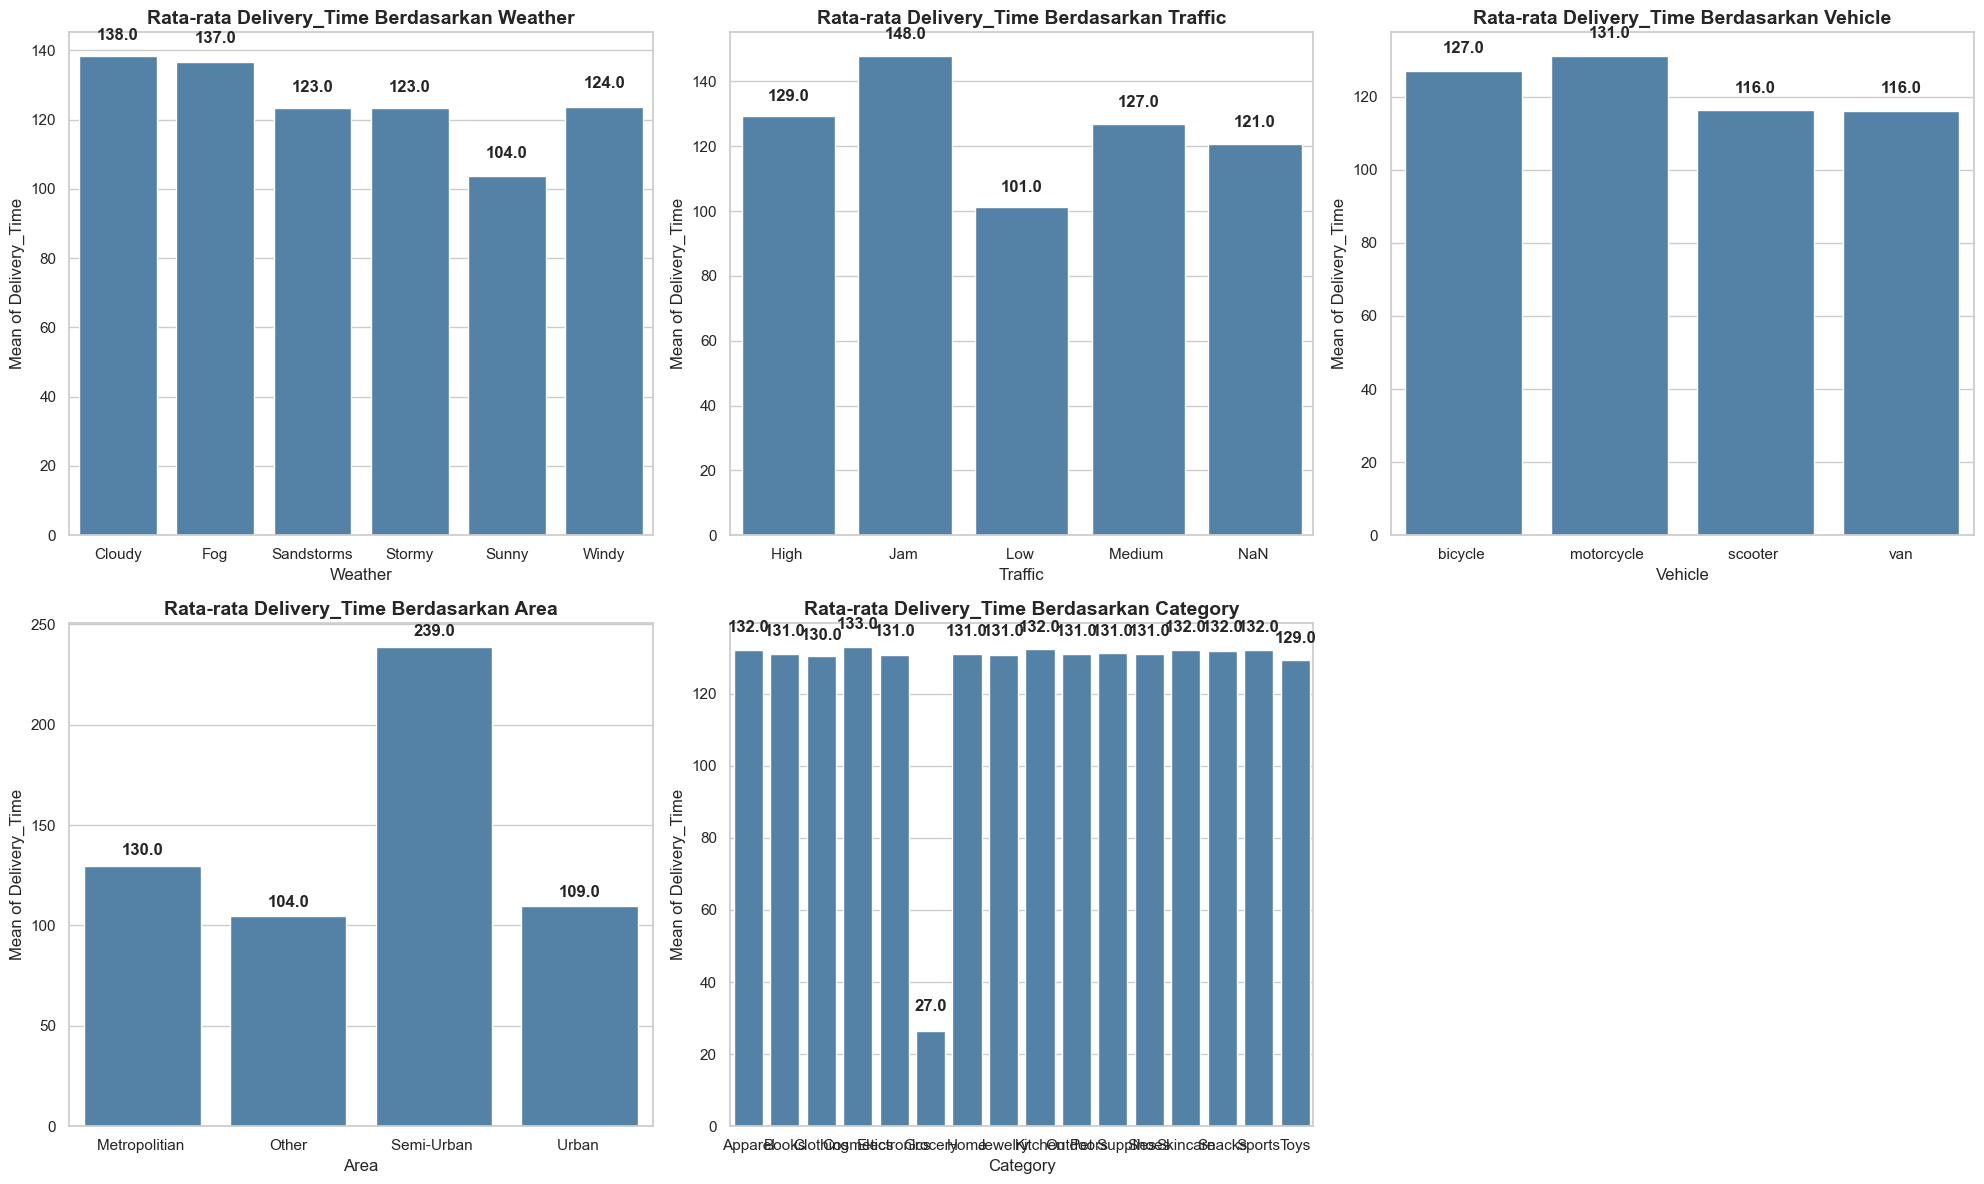

In [48]:
n_show = len(feature_categori)
n_cols = 3
nrows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(nrows, n_cols, figsize=(20, 6 * nrows))
axes = axes.flatten()

for i, col in enumerate(feature_categori):
    group_mean = df.groupby(col)[y_target].mean().reset_index().round()
    sns.barplot(data=df, x=col, y=y_target, color='steelblue', errorbar=None, ax=axes[i],order=group_mean[col]) 
    axes[i].set_title(f"Rata-rata {y_target} Berdasarkan {col}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel(f"Mean of {y_target}", fontsize=12)
    for j, v in enumerate(group_mean[y_target]):
        axes[i].text(j,v+5,str(v), ha="center", fontweight="bold")
for j in range(n_show, len(axes)):
        axes[j].axis('off')
    
plt.tight_layout()
plt.show()

## 10. Multivariat Analysis

In [49]:
df_target = df.copy()
feature_numerik = df_target.select_dtypes(include=[np.number]).columns.to_list()
corrs_all = df_target[feature_numerik].corr()[y_target].abs().sort_values(ascending=False)
top_features = [x for x in corrs_all.index if x != y_target][:20]

print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Agent_Rating       0.290
Agent_Age          0.255
Store_Latitude     0.017
Drop_Latitude      0.017
Drop_Longitude     0.012
Store_Longitude    0.011
Name: Delivery_Time, dtype: float64


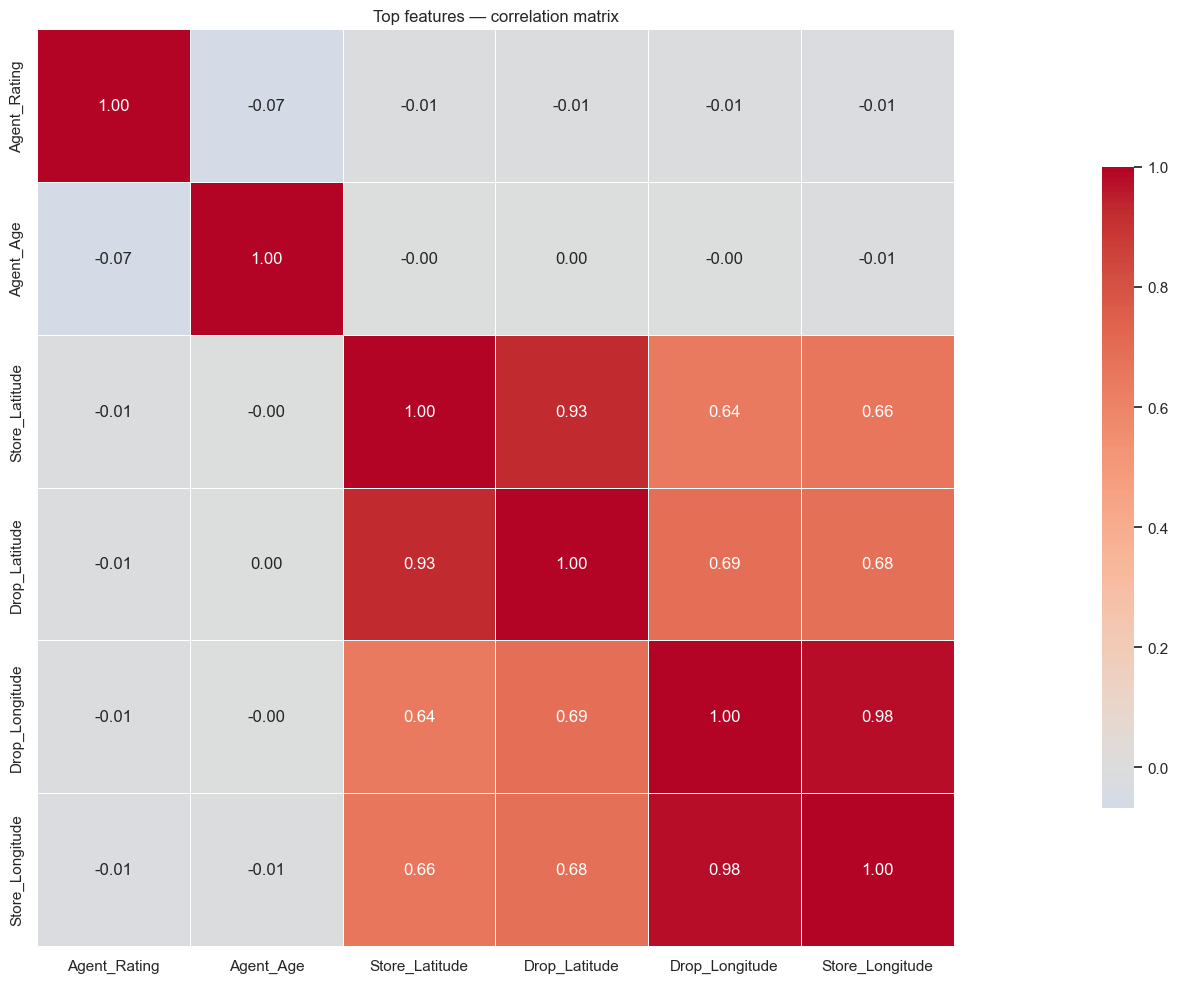

In [50]:
corr_matrix = df[top_features].corr()
plt.figure(figsize=(30,10))
sns.heatmap(corr_matrix,annot=True,fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix')
plt.tight_layout()
plt.show()

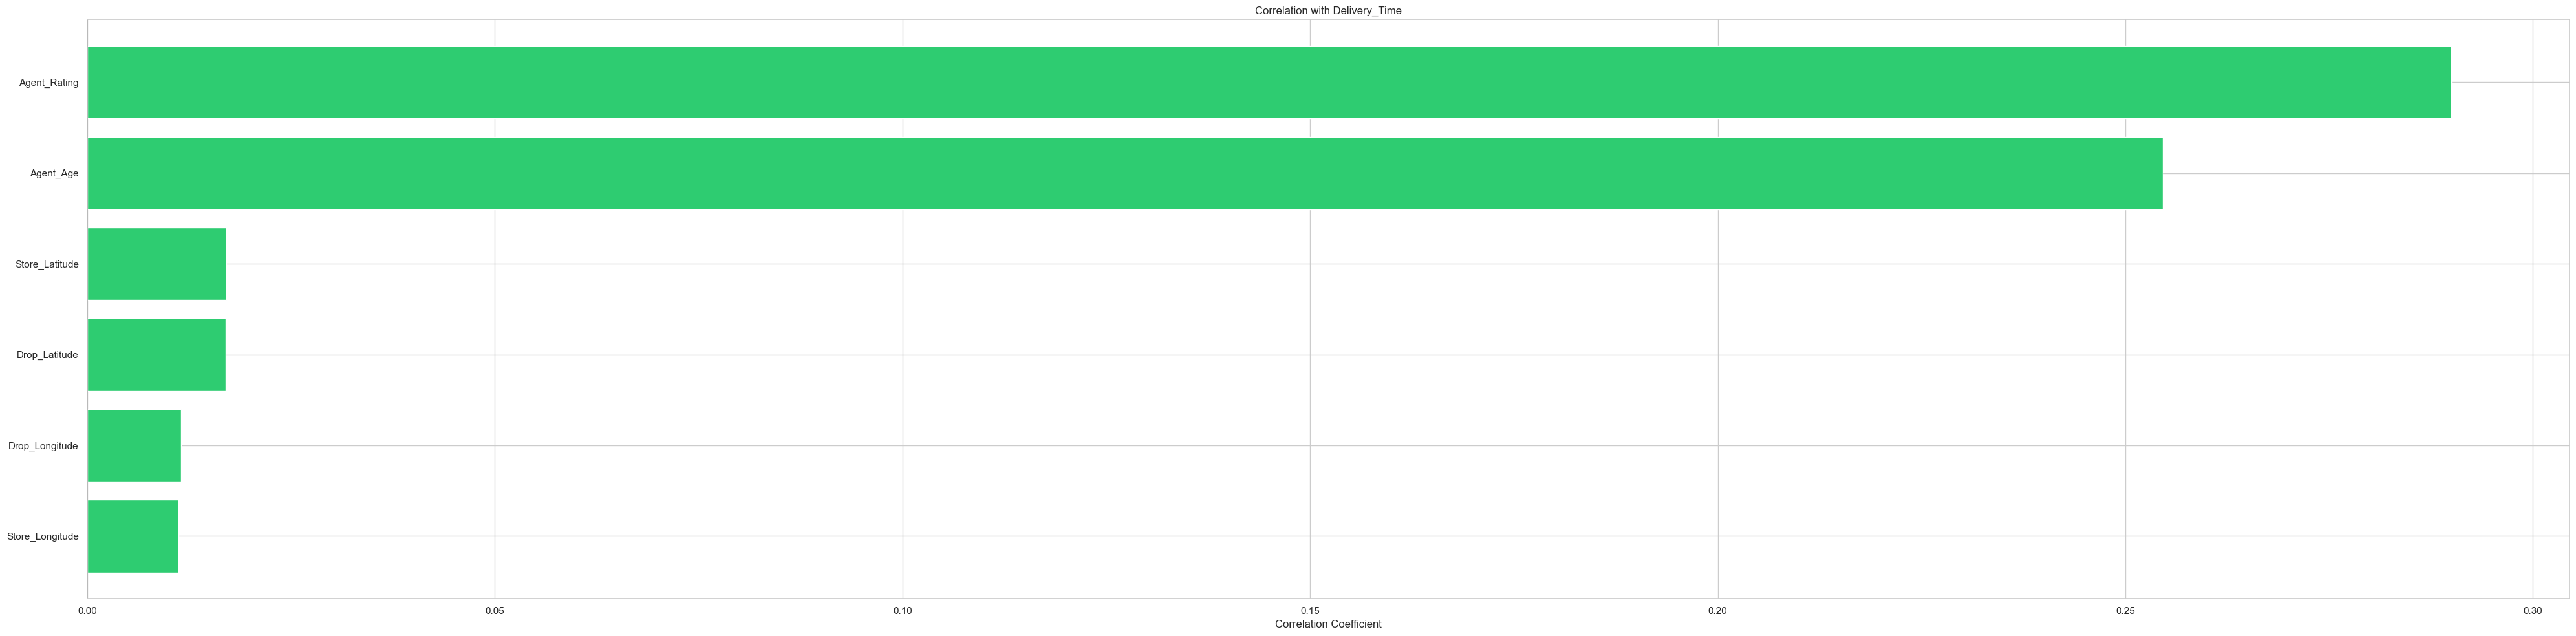

In [51]:
target_corr = df[feature_numerik].corr()[y_target].abs().drop(y_target).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(40, 10))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title(f"Correlation with {y_target}")
ax.set_xlabel("Correlation Coefficient")
ax.axvline(x=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 11. Deep Analysis Features Datetime

In [52]:
feature_time = ['Order_Date', 'Order_Time', 'Pickup_Time','Delivery_Time']
df_copy = df[feature_time].copy()

df_copy['Order_Datetime'] = pd.to_datetime( df_copy['Order_Date'].astype(str) + ' ' + df_copy['Order_Time'].astype(str), errors='coerce')
df_copy['Pickup_Datetime'] = pd.to_datetime(df_copy['Order_Date'].astype(str) + ' ' + df_copy['Pickup_Time'].astype(str), errors='coerce')
df_copy = df_copy.dropna(subset=['Order_Datetime', 'Pickup_Datetime'])

mask = df_copy['Pickup_Datetime'] < df_copy['Order_Datetime']
df_copy.loc[mask, 'Pickup_Datetime'] = df_copy.loc[mask, 'Pickup_Datetime'] + pd.Timedelta(days=1)

df_copy['Prep_Time_Min'] = (df_copy['Pickup_Datetime'] -  df_copy['Order_Datetime']).dt.total_seconds() / 60
df_copy['Order_Hour'] = df_copy['Order_Datetime'].dt.hour
df_copy['DayOfWeek'] = df_copy['Order_Datetime'].dt.day_name()
df_copy['Is_Weekend'] = np.where(df_copy['Order_Datetime'].dt.day_of_week.isin([5, 6]), 'Weekend', 'Weekday')

cols_to_drop = ['Order_Date', 'Order_Time', 'Pickup_Time', 'Order_Datetime', 'Pickup_Datetime']
df_copy = df_copy.drop(columns=cols_to_drop)

cols_to_convert = ['Prep_Time_Min', 'Order_Hour']
for col in cols_to_convert:
    df_copy[col] = df_copy[col].astype(str)
    
df_copy.head()

,Delivery_Time,Prep_Time_Min,Order_Hour,DayOfWeek,Is_Weekend
0,120,15.0,11,Saturday,Weekend
1,165,5.0,19,Friday,Weekday
2,130,15.0,8,Saturday,Weekend
3,105,10.0,18,Tuesday,Weekday
4,150,15.0,13,Saturday,Weekend


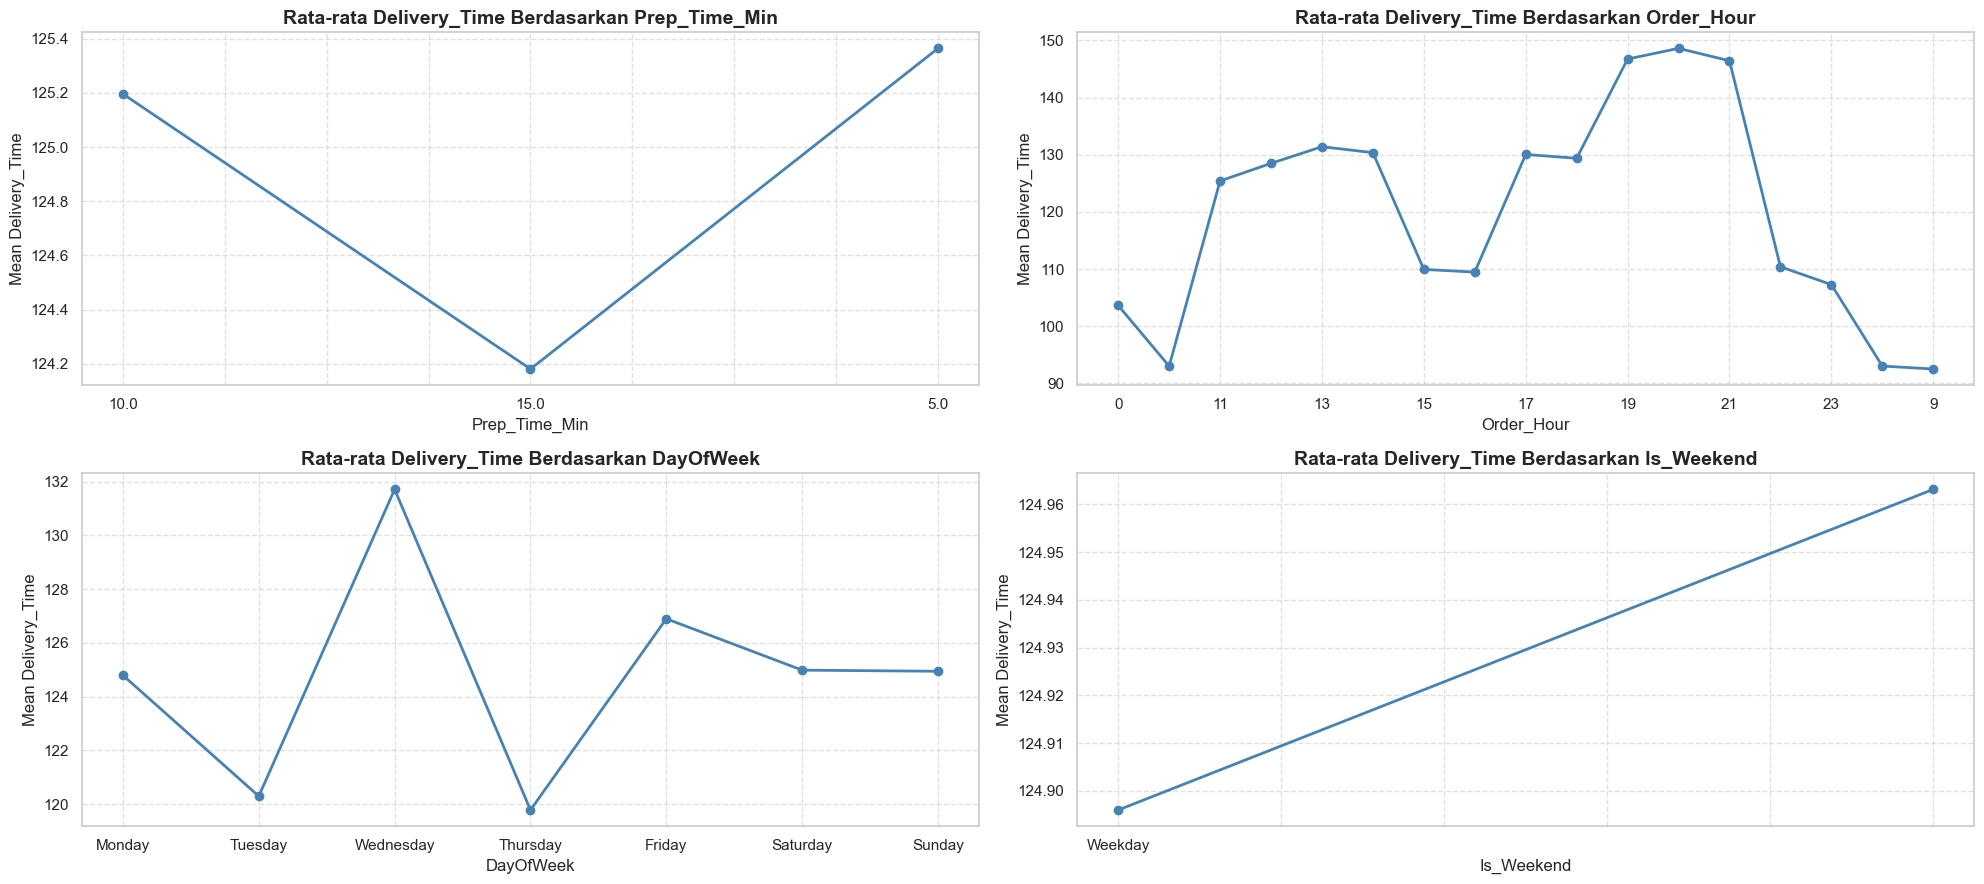

In [53]:
feature_time = df_copy.select_dtypes(include='object').columns
n_show = len(feature_time)
n_cols = 2
nrows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(nrows, n_cols, figsize=(20, 4.5 * nrows))
axes = axes.flatten()

for i, feature in enumerate(feature_time):
    if feature == 'DayOfWeek':
        urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        data_plot = df_copy.groupby(feature)[y_target].mean().reindex(urutan_hari)
    elif feature == 'Is_Weekend':
        urutan_hari = ['Weekday','Weekend']
        data_plot = df_copy.groupby(feature)[y_target].mean().reindex(urutan_hari)
    else:
        data_plot = df_copy.groupby(feature)[y_target].mean()
    data_plot.plot(ax=axes[i], marker='o', color='steelblue', linewidth=2)
    axes[i].set_title(f'Rata-rata {y_target} Berdasarkan {feature}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel(f'Mean {y_target}', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

for j in range(n_show, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 12. Summary of Key Findings

In [54]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Target mean', 'Target median',
               'Target stddev', 'Target min', 'Target max', 'Target skewness',
               'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df), df.shape[1] - 1,
        round(df[y_target].mean(), 2),
        round(df[y_target].median(), 2),
        round(df[y_target].std(), 2),
        round(df[y_target].min(), 2),
        round(df[y_target].max(), 2),
        round(df[y_target].skew(), 3),
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,43739
1,Total features,14
2,Target mean,124.91
3,Target median,125.0
4,Target stddev,51.92
5,Target min,10
6,Target max,270
7,Target skewness,0.189
8,Top correlated feature,Agent_Rating
9,Top correlation value,0.29
